# Homework 1 — Ensemble of mlp_4out_emb and LightGBM

**Question:** does averaging the MLP with LightGBM beat the MLP alone?

- **mlp_4out_emb:** the submitted model ([mlp.ipynb](mlp.ipynb)), Adam, 20 epochs
  ([epochs_test.ipynb](epochs_test.ipynb)).
- **lgbm:** LightGBM on the same 33 features, untuned (500 trees, learning rate 0.1, 63 leaves), as in mlp.ipynb.
- **lgbm_building:** the same plus `building_id` as a categorical feature. Plain lgbm doesn't know which building a row
  is, which is what makes the MLP strong.

**Blend:** a weighted average of the `log1p` predictions, `w · mlp + (1 − w) · lgbm`, which keeps the ensemble in the
space RMSLE is measured in.

**Honest scoring:** the weight is chosen on 3 folds and scored on the 4th (leave one fold out), so the ensemble isn't
tuned on its own validation rows.

Same 4 seasonal folds as every notebook, 2M training / 500K validation rows each. The last section repeats the two
best models with 4M training rows.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS, METERS
from ashrae.data import read_processed, split
from ashrae.features import build_features
from ashrae.metrics import rmsle
from ashrae.modeling import MeterMLP, make_loaders, predict
from ashrae.tracking import Experiment

# Imported after torch: loading LightGBM first crashes the kernel on macOS (both ship an OpenMP runtime).
import lightgbm as lgb

EPOCHS = 20
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold, as in the other notebooks
LGBM_PARAMS = {"n_estimators": 500, "learning_rate": 0.1, "num_leaves": 63}
LGBMS = ["lgbm", "lgbm_building"]
experiment = Experiment("ashrae-ensemble")

2026/09/27 21:29:11 INFO mlflow.tracking.fluent: Experiment with name 'ashrae-ensemble' does not exist. Creating a new experiment.


MLflow: sqlite:////Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/mlflow.db, experiment 'ashrae-ensemble', session 2026-09-27 21:29:11


## Training

Per fold: the MLP, then both LightGBMs on the same rows. Validation predictions are kept (clipped at 0, like the
metric) to blend afterwards.

In [2]:
df = read_processed()
n_buildings = int(df.building_id.max()) + 1
BUILDING = pd.CategoricalDtype(range(n_buildings))


def with_building(X, rows):
    return X.assign(building_id=rows.building_id.astype(int).astype(BUILDING).to_numpy())


def run_fold(fold, n_train, models):
    """Validation predictions of `models` for one fold, trained on `n_train` rows."""
    train_df, val_df = split(df, FOLDS[fold], n_train, N_VAL)
    year_median = train_df.year_built.median()
    X_train, X_val = build_features(train_df, year_median), build_features(val_df, year_median)
    y_train = np.log1p(train_df.meter_reading.to_numpy(dtype="float32"))
    preds = {}
    if "mlp_4out_emb" in models:
        train_loader, val_loader, _ = make_loaders(train_df, val_df, X_train, X_val)
        model, _ = experiment.fit(lambda: MeterMLP(X_train.shape[1], n_buildings), train_loader,
                                  run_name=f"mlp_4out_emb | {n_train:,} rows | {fold}", epochs=EPOCHS,
                                  tags={"model": "mlp_4out_emb", "fold": fold, "n_train": n_train})
        preds["mlp_4out_emb"] = predict(model, val_loader)
    for name in [m for m in models if m in LGBMS]:
        Xtr, Xv = (with_building(X_train, train_df), with_building(X_val, val_df)) if name == "lgbm_building" \
            else (X_train, X_val)
        # n_jobs=1: multi-threaded LightGBM segfaults once torch has loaded its OpenMP runtime
        model = lgb.LGBMRegressor(**LGBM_PARAMS, random_state=0, verbose=-1, n_jobs=1).fit(Xtr, y_train)
        preds[name] = np.clip(model.predict(Xv), 0, None)
    return {"y": np.log1p(val_df.meter_reading.to_numpy(dtype="float32")), "anomaly": val_df.anomaly.to_numpy(),
            "meter": val_df.meter.to_numpy(), "pred": preds}


oof = {}
for fold in FOLDS:
    oof[fold] = run_fold(fold, N_TRAIN, ["mlp_4out_emb", *LGBMS])
    print(fold + ": " + ", ".join(f"{m} {rmsle(oof[fold]['y'], p):.3f}" for m, p in oof[fold]["pred"].items()))

/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


Jan–Mar: mlp_4out_emb 1.409, lgbm 1.487, lgbm_building 1.434


/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


Apr–Jun: mlp_4out_emb 1.211, lgbm 1.297, lgbm_building 1.231


/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


Jul–Sep: mlp_4out_emb 1.028, lgbm 1.172, lgbm_building 1.087


/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


Oct–Dec: mlp_4out_emb 1.102, lgbm 1.164, lgbm_building 1.116


## Blend weight

RMSLE of the blend for every MLP weight `w`, per fold and averaged. `w = 1` is the MLP alone, `w = 0` LightGBM alone.

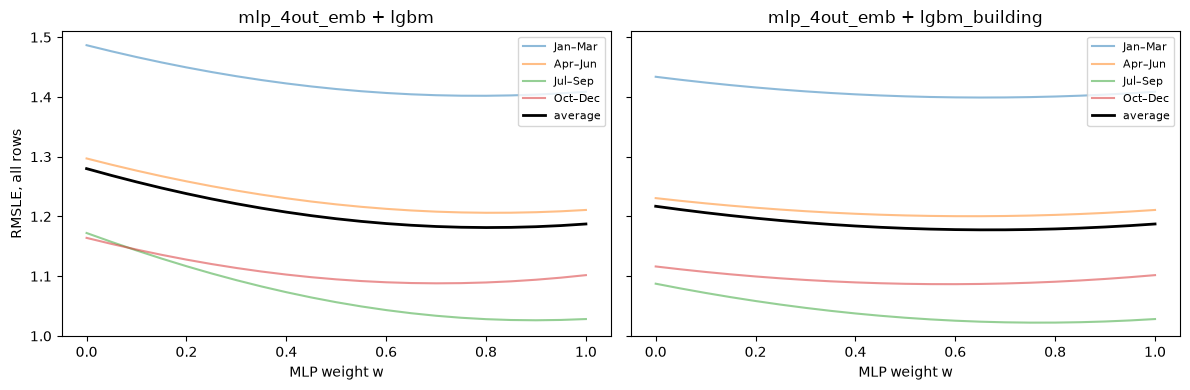

In [3]:
WEIGHTS = np.round(np.linspace(0, 1, 21), 2)  # weight of the MLP


def blend(data, other, w):
    return w * data["pred"]["mlp_4out_emb"] + (1 - w) * data["pred"][other]


def curve(other, rows="all"):
    """RMSLE per weight (rows) and fold (columns)."""
    def score(data, w):
        keep = ~data["anomaly"] if rows == "clean" else slice(None)
        return rmsle(data["y"][keep], blend(data, other, w)[keep])
    return pd.DataFrame({fold: [score(data, w) for w in WEIGHTS] for fold, data in oof.items()}, index=WEIGHTS)


curves = {other: curve(other) for other in LGBMS}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (other, c) in zip(axes, curves.items()):
    c.plot(ax=ax, alpha=0.5)
    c.mean(axis=1).plot(ax=ax, color="black", lw=2, label="average")
    ax.set(title=f"mlp_4out_emb + {other}", xlabel="MLP weight w", ylabel="RMSLE, all rows")
    ax.legend(fontsize=8)
plt.tight_layout()

## Scores

Singles and blends per fold. Blends use the weight chosen on the other three folds (shown in brackets).

In [4]:
rows = {}
for rows_kind in ["all", "clean"]:
    for model in ["mlp_4out_emb", *LGBMS]:
        rows[(rows_kind, model)] = {
            fold: rmsle(d["y"][~d["anomaly"]] if rows_kind == "clean" else d["y"],
                        d["pred"][model][~d["anomaly"]] if rows_kind == "clean" else d["pred"][model])
            for fold, d in oof.items()}
    for other in LGBMS:
        c = curve(other, rows_kind) if rows_kind == "clean" else curves[other]
        chosen = {fold: float(curves[other].drop(columns=fold).mean(axis=1).idxmin()) for fold in FOLDS}  # on all rows
        rows[(rows_kind, f"blend with {other}")] = {fold: c.loc[chosen[fold], fold] for fold in FOLDS}
        if rows_kind == "all":
            print(f"blend with {other}: MLP weight chosen per held-out fold {chosen}")

scores = pd.DataFrame(rows).T[list(FOLDS)]
scores["average"] = scores.mean(axis=1)
display(scores.round(3).rename_axis(["rows", "model"]))

blend with lgbm: MLP weight chosen per held-out fold {'Jan–Mar': 0.8, 'Apr–Jun': 0.8, 'Jul–Sep': 0.75, 'Oct–Dec': 0.85}
blend with lgbm_building: MLP weight chosen per held-out fold {'Jan–Mar': 0.65, 'Apr–Jun': 0.7, 'Jul–Sep': 0.6, 'Oct–Dec': 0.7}


Jan–Mar  Apr–Jun  Jul–Sep  Oct–Dec  average
rows  model                                                                
all   mlp_4out_emb                1.409    1.211    1.028    1.102    1.187
      lgbm                        1.487    1.297    1.172    1.164    1.280
      lgbm_building               1.434    1.231    1.087    1.116    1.217
      blend with lgbm             1.402    1.206    1.030    1.091    1.183
      blend with lgbm_building    1.399    1.201    1.026    1.088    1.178
clean mlp_4out_emb                0.921    0.881    0.880    1.014    0.924
      lgbm                        1.049    1.005    1.050    1.078    1.045
      lgbm_building               0.951    0.909    0.952    1.024    0.959
      blend with lgbm             0.912    0.876    0.884    1.002    0.919
      blend with lgbm_building    0.903    0.867    0.879    0.997    0.911

## Why it helps (or not): error correlation and meters

Two models average well when their errors differ. Correlation of the residuals (prediction − truth) on clean rows,
fold average; and the fold-average RMSLE per meter type at the weight that's best on average.

In [5]:
corr = {other: np.mean([np.corrcoef(d["pred"]["mlp_4out_emb"][~d["anomaly"]] - d["y"][~d["anomaly"]],
                                     d["pred"][other][~d["anomaly"]] - d["y"][~d["anomaly"]])[0, 1]
                         for d in oof.values()]) for other in LGBMS}
display(pd.Series(corr, name="residual correlation with mlp_4out_emb").round(3).to_frame())

best_other = min(LGBMS, key=lambda o: scores.loc[("all", f"blend with {o}"), "average"])
w_best = float(curves[best_other].mean(axis=1).idxmin())
per_meter = {}
for m, name in METERS.items():
    per_meter[name] = {}
    for label, get in [("mlp_4out_emb", lambda d: d["pred"]["mlp_4out_emb"]), (best_other, lambda d: d["pred"][best_other]),
                       (f"blend, w = {w_best}", lambda d: blend(d, best_other, w_best))]:
        per_meter[name][label] = np.mean([rmsle(d["y"][d["meter"] == m], get(d)[d["meter"] == m]) for d in oof.values()])
    # best weight for this meter alone, on the fold average
    per_meter[name]["best w for this meter"] = WEIGHTS[np.argmin([np.mean([
        rmsle(d["y"][d["meter"] == m], blend(d, best_other, w)[d["meter"] == m]) for d in oof.values()]) for w in WEIGHTS])]
display(pd.DataFrame(per_meter).T.round(3).rename_axis("fold average, all rows"))

,residual correlation with mlp_4out_emb
lgbm,0.814
lgbm_building,0.882


,mlp_4out_emb,lgbm_building,"blend, w = 0.65",best w for this meter
"fold average, all rows",,,,
electricity,0.941,0.975,0.941,0.80
chilledwater,1.374,1.392,1.350,0.55
steam,1.515,1.560,1.501,0.70
hotwater,1.564,1.583,1.545,0.60


## More training rows

The folds use 2M of the ~14M clean training rows available per fold. The MLP and the better LightGBM again with 4M
rows (same validation rows), and their blend at the weight chosen above.

In [6]:
N_TRAIN_BIG = 4_000_000
big = {}
for fold in FOLDS:
    big[fold] = run_fold(fold, N_TRAIN_BIG, ["mlp_4out_emb", best_other])
    assert np.array_equal(big[fold]["y"], oof[fold]["y"])  # same validation rows as above

size_rows = {}
for label, runs in [(f"{N_TRAIN:,} rows", oof), (f"{N_TRAIN_BIG:,} rows", big)]:
    for model in ["mlp_4out_emb", best_other]:
        size_rows[(label, model)] = {fold: rmsle(d["y"], d["pred"][model]) for fold, d in runs.items()}
    size_rows[(label, f"blend, w = {w_best}")] = {fold: rmsle(d["y"], blend(d, best_other, w_best))
                                                 for fold, d in runs.items()}
size_table = pd.DataFrame(size_rows).T[list(FOLDS)]
size_table["average"] = size_table.mean(axis=1)
display(size_table.round(3).rename_axis(["training rows", "model"]))

/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


Jan–Mar  Apr–Jun  Jul–Sep  Oct–Dec  average
training rows  model                                                       
2,000,000 rows mlp_4out_emb       1.409    1.211    1.028    1.102    1.187
               lgbm_building      1.434    1.231    1.087    1.116    1.217
               blend, w = 0.65    1.399    1.200    1.024    1.087    1.178
4,000,000 rows mlp_4out_emb       1.414    1.216    1.013    1.101    1.186
               lgbm_building      1.436    1.233    1.083    1.111    1.216
               blend, w = 0.65    1.403    1.202    1.012    1.085    1.176

## Findings

Fold averages on all rows unless noted; blends scored with the weight chosen on the other three folds.

- **The ensemble helps a little, in every fold.** mlp_4out_emb + lgbm_building: 1.187 → 1.178 (clean rows
  0.924 → 0.911), better in all 4 folds. The chosen MLP weight is stable, 0.6–0.7. With plain lgbm the gain is smaller
  (1.183).
- **Telling LightGBM the building is worth 0.063:** lgbm 1.280 → lgbm_building 1.217. It's still behind the MLP
  (1.187) in every fold.
- **The gain is small because the errors are alike:** residual correlation 0.88 with lgbm_building. Both models miss
  the same rows, mostly anomalies and seasonal effects that neither can see.
- **The blend helps the heating and cooling meters** (chilled water 1.374 → 1.350, steam 1.515 → 1.501, hot water
  1.564 → 1.545), not electricity (0.941 → 0.941). The best weight per meter ranges from 0.55 (chilled water) to 0.8
  (electricity), but that was read off all four folds, not validated.
- **Twice the training rows changes nothing:** 4M instead of 2M gives 1.186 vs 1.187 for the MLP, 1.216 vs 1.217 for
  lgbm_building, 1.176 vs 1.178 for the blend. Data size isn't what limits either model.

One seed per run; the blend's gain (0.009) is near the ~0.01 noise level, but it holds in every fold.

## Recommendations

1. **Submit the blend:** 0.65 · mlp_4out_emb + 0.35 · lgbm_building in `log1p` space, both retrained on all of 2016.
   Expected gain over the MLP alone: ~0.01. Check it on the leaderboard, which also shows whether the validation tracks
   the test set.
2. **Data size:** keep 2M rows per fold for experiments; 4M costs twice the time for no gain. For the final models,
   train on all of 2016 anyway, since it's cheap once.
3. **Tune LightGBM next.** It's untuned (500 trees, learning rate 0.1, 63 leaves), and the building feature alone gained
   0.063. Try a lower learning rate with more trees and early stopping on each fold, `num_leaves` 31–255, and
   `min_data_in_leaf` for the building categorical. Run it in a notebook that doesn't import torch, so LightGBM can use
   all cores (here it's limited to one thread).
4. **MLP tuning with the most room:** validation still improves at epoch 20 ([epochs_test.ipynb](epochs_test.ipynb)),
   so try 30–40 epochs or a learning-rate schedule. More layers ([layers_test.ipynb](layers_test.ipynb)),
   regularization ([regularization_test.ipynb](regularization_test.ipynb)) and more rows (above) don't help.
5. **For a bigger ensemble gain, add models that err differently.** Two models with 0.88-correlated errors can't gain
   much. Candidates, untested: MLP seeds averaged, per-meter weights (validated leave-one-fold-out like the global
   weight), or a model with different inputs, e.g. lagged and rolling weather, which top ASHRAE solutions used.
6. **The anomaly rows remain the biggest error** (up to 0.48 per fold,
   [season_validation.ipynb](../validation/season_validation.ipynb)); no ensemble of these inputs fixes that.